In [1]:
import xarray as xr
import numpy as np
from subs1_utils import *
import matplotlib.pyplot as plt

import torch
import torch_harmonics.distributed as dist
import torch_harmonics as th

import xesmf as xe


In [2]:
def vertical_profile_tropics(kmax=26, peak=8, sigma=3.5):
    k_idx = np.arange(kmax)
    vert = np.exp(-0.5*((k_idx - peak)/sigma)**2)
    return vert / vert.sum()

def tropical_climatological_heating(ftemp, dlatlon, kmax=26, trop_lat=10):
    """
    Compute climatological JJA heating only in the tropics with a top-heavy profile.
    """
    
    dsht = dist.DistributedRealSHT(jmax, imax, lmax=mw, mmax=zw, grid="legendre-gauss", csphase=False)
    disht = dist.DistributedInverseRealSHT(jmax, imax, lmax=mw, mmax=zw, grid="legendre-gauss", csphase=False)

    # 1. Read CMAP precipitation (mm/day)
    Dprec = xr.open_dataset(ftemp).sel(time=slice('1979-01-01','2023-12-31'))
    prec_clim = Dprec.precip.groupby('time.month').mean(dim='time')
    prec_clim_jja = prec_clim.sel(month=[6,7,8]).mean('month')  # JJA climatology

    # 2. Regrid to Gaussian grid
    regridder = xe.Regridder(prec_clim_jja, dlatlon, 'bilinear', reuse_weights=False)
    precip_gauss = regridder(prec_clim_jja).values  # (nlat, nlon)

    # 3. Convert precip to heating (K/day)
    Lv, rhow, Cp, Ps, grav = 2.5e6, 1000.0, 1005.0, 101325.0, 9.8
    beta = (Lv * rhow / Cp) * (grav / Ps) / (1000.0 * 86400.0)
    heat_base = precip_gauss * beta  # (nlat, nlon)    

    # 4. Apply tropical mask
    lats = dlatlon['lat'].values
    trop_mask = (np.abs(lats) <= trop_lat).astype(float)[:, None]  # (nlat,1)
    heat_base *= trop_mask

    # Apply spectral filtering
    heat_spec = dsht(torch.from_numpy(heat_base).float())
    heat_spec_t = disht(heat_spec)

    # 5. Apply vertical structure (top heavy)
    vert_trop = vertical_profile_tropics(kmax=kmax, peak=8, sigma=3.5)[:, None, None]  # (kmax,1,1)
    heat3d = torch.from_numpy(vert_trop).float() * torch.from_numpy(heat_base).float()[None,:,:]

    return heat3d  # (kmax, nlat, nlon)

In [3]:
def plot_vertical_profile_tropics(kmax=26, peak=8, sigma=3.5):
    """
    Plot the tropical vertical heating profile (top-heavy).
    """
    vert = vertical_profile_tropics(kmax=26, peak=8, sigma=3.5)

    plt.figure(figsize=(4,6))
    plt.plot(vert, np.arange(kmax), color="tab:orange", lw=2, label="Tropical vertical weights")
    plt.gca().invert_yaxis()  # 0 = top, kmax = bottom
    plt.xlabel("Weight")
    plt.ylabel("Vertical level k (0=top)")
    plt.title("Tropical Vertical Heating Profile")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    return vert

In [4]:
jmax = 96
imax = 192
kmax = 26
mw = 63
zw = 63

# Use existing precompute_latitudes function
cost_lg, wlg, lats_rad = precompute_latitudes(jmax)
lats = 90 - 180*lats_rad/np.pi
lons = np.linspace(0.0, 360.0-360.0/imax, imax)
dlatlon = xr.Dataset({"lat": lats, "lon": lons})

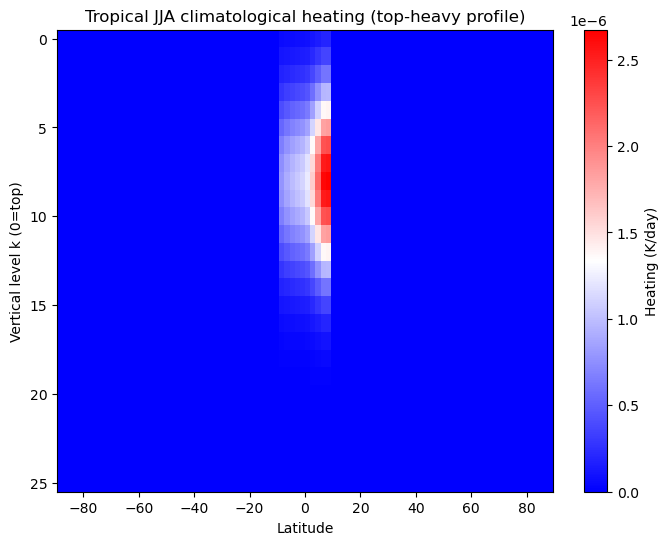

In [5]:
ftemp = 'http://psl.noaa.gov/thredds/dodsC/Datasets/cmap/enh/precip.mon.mean.nc'
heat3d = tropical_climatological_heating(ftemp, dlatlon, kmax=26, trop_lat=10)

plt.figure(figsize=(8,6))
zonal_mean = heat3d.mean(dim=2).numpy()
plt.pcolormesh(dlatlon['lat'].values, np.arange(26), zonal_mean, cmap='bwr', shading='auto')
plt.gca().invert_yaxis()
plt.colorbar(label="Heating (K/day)")
plt.xlabel("Latitude")
plt.ylabel("Vertical level k (0=top)")
plt.title("Tropical JJA climatological heating (top-heavy profile)")
plt.show()

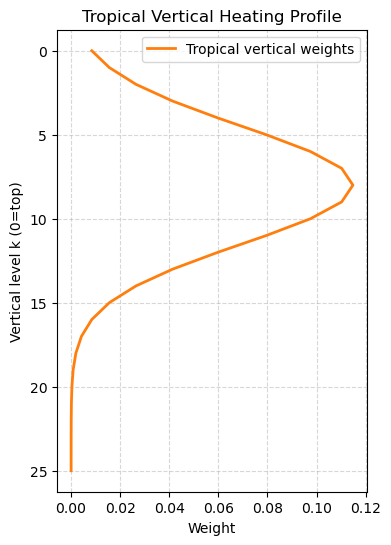

In [6]:
vert_trop = plot_vertical_profile_tropics(kmax=26, peak=8, sigma=3.5)


In [8]:
fullpath =  '/data/esplab/kpegion/projects/AGCM/MultiThread_Model/preprocess__zw_63__kmax_26_JJA/'
filestub='heatingJJA_1979-2023_tropics'
ofname=fullpath+'heat.ggrid_'+filestub+'.pt'
torch.save(heat3d,ofname)